In [32]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv("final_gloss_files.csv")
df.head()

,gloss,count,files_names
0,HE,30,HE 1.npy;HE 10.npy;HE 11.npy;HE 12.npy;HE 13.n...
1,WE,31,WE 1.npy;WE 10.npy;WE 11.npy;WE 12.npy;WE 13.n...
2,THEY,58,THEY 1.npy;THEY 10.npy;THEY 11.npy;THEY 12.npy...
3,WHAT,63,WHAT 1.npy;WHAT 10.npy;WHAT 11.npy;WHAT 12.npy...
4,WHEN,31,WHEN 1.npy;WHEN 10.npy;WHEN 11.npy;WHEN 12.npy...


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   gloss        501 non-null    object
 1   count        501 non-null    int64 
 2   files_names  501 non-null    object
dtypes: int64(1), object(2)
memory usage: 11.9+ KB


In [35]:
df.describe()

,count
count,501.000000
mean,32.882236
std,10.861681
min,17.000000
25%,29.000000
50%,30.000000
75%,31.000000
max,121.000000


In [36]:
# Basic stats
print("\n===== Dataset Stats =====")
print("Total glosses:", len(df))
print("Total files:", df["count"].sum())
print("\nMean samples per gloss:", round(df["count"].mean(), 3))
print("Median samples per gloss:", round(df["count"].median(), 3))
print("Std deviation:", round(df["count"].std(), 3))
print("\nMin samples:", df["count"].min())
print("Max samples:", df["count"].max())


===== Dataset Stats =====
Total glosses: 501
Total files: 16474

Mean samples per gloss: 32.882
Median samples per gloss: 30.0
Std deviation: 10.862

Min samples: 17
Max samples: 121


In [37]:
# Top / Bottom glosses
print("\n===== TOP 10 GLOSSES =====")
print(df.sort_values("count", ascending=False).head(10)[["gloss", "count"]])
print("\n===== BOTTOM 10 GLOSSES =====")
print(df.sort_values("count", ascending=True).head(10)[["gloss", "count"]])


===== TOP 10 GLOSSES =====
        gloss  count
376    JACKET    121
487     RIGHT     94
421   PATIENT     92
168  WHAT FOR     89
415      FALL     63
117  HOSPITAL     63
3        WHAT     63
37        EAT     63
155       EAT     63
115      SHOP     63

===== BOTTOM 10 GLOSSES =====
          gloss  count
373         YOU     17
374       YOUNG     22
347          ME     23
348        MEET     23
375        YOUR     24
273     ALL DAY     24
276    ALL OVER     24
261   AFTERNOON     24
284     AMAZING     24
235  ABBREVIATE     24


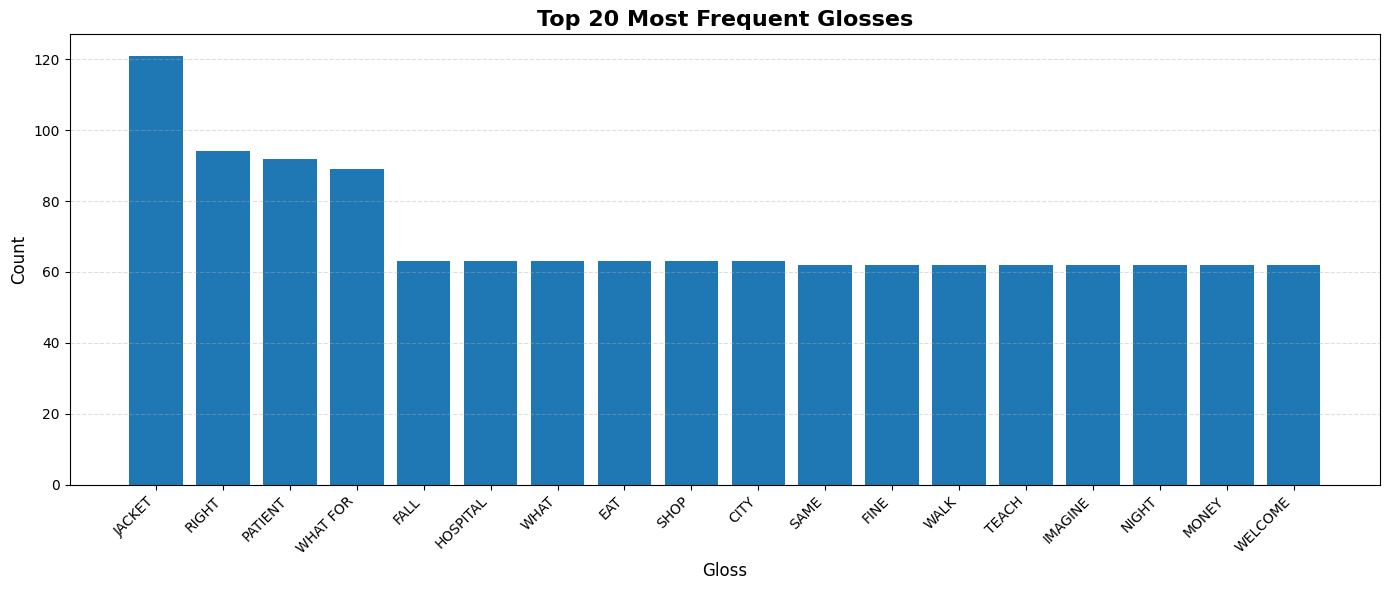

In [38]:
top20 = df.sort_values("count", ascending=False).head(20)

plt.figure(figsize=(14, 6))
plt.bar(top20["gloss"], top20["count"])

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

plt.title("Top 20 Most Frequent Glosses", fontsize=16, fontweight="bold")
plt.xlabel("Gloss", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
# save image
plt.savefig("visuals/top20_glosses.png", dpi=300, bbox_inches="tight")
plt.show()

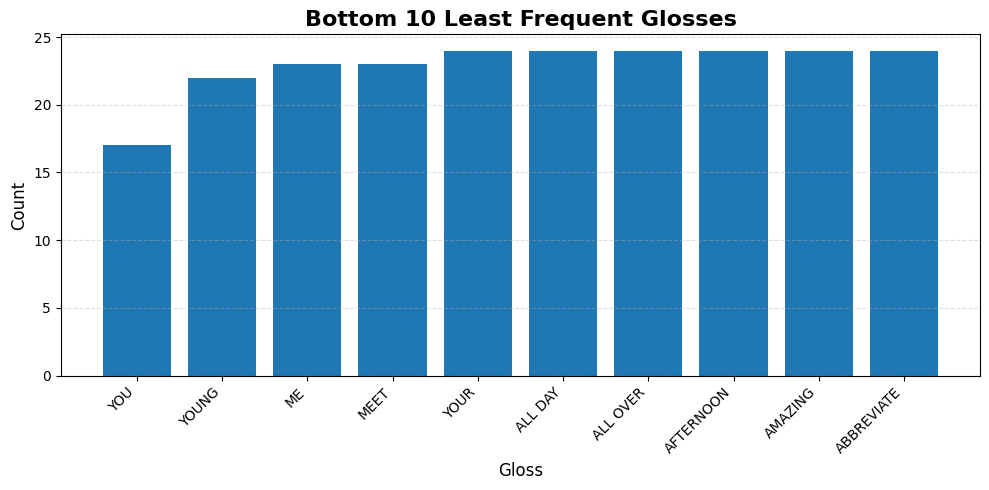

In [39]:
bottom10 = df.sort_values("count", ascending=True).head(10)

plt.figure(figsize=(10, 5))
plt.bar(bottom10["gloss"], bottom10["count"])

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

plt.title("Bottom 10 Least Frequent Glosses", fontsize=16, fontweight="bold")
plt.xlabel("Gloss", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
# save image
plt.savefig("visuals/bottom10_glosses.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
folder = Path("raw_landmarks")
output_dir = Path("visuals")
output_dir.mkdir(exist_ok=True)

frame_counts = []

# Load frame lengths
for file in folder.rglob("*.npy"):
    try:
        arr = np.load(file, allow_pickle=True)
        frames = arr.shape[0] if len(arr.shape) > 1 else len(arr)
        frame_counts.append(frames)
    except:
        continue

frame_counts = np.array(frame_counts)

In [42]:
# Stats
min_v = frame_counts.min()
max_v = frame_counts.max()
mean_v = frame_counts.mean()
median_v = np.median(frame_counts)
p90 = np.percentile(frame_counts, 90)
p95 = np.percentile(frame_counts, 95)
p99 = np.percentile(frame_counts, 99)

# PRINT stats
print("===== FRAME STATISTICS =====")
print("Total files:", len(frame_counts))
print("Min frames:", min_v)
print("Max frames:", max_v)
print("Mean frames:", round(mean_v, 2))
print("Median frames:", median_v)
print("90th percentile:", round(p90, 2))
print("95th percentile:", round(p95, 2))
print("99th percentile:", round(p99, 2))

===== FRAME STATISTICS =====
Total files: 16474
Min frames: 10
Max frames: 664
Mean frames: 78.97
Median frames: 72.0
90th percentile: 125.0
95th percentile: 151.0
99th percentile: 187.0


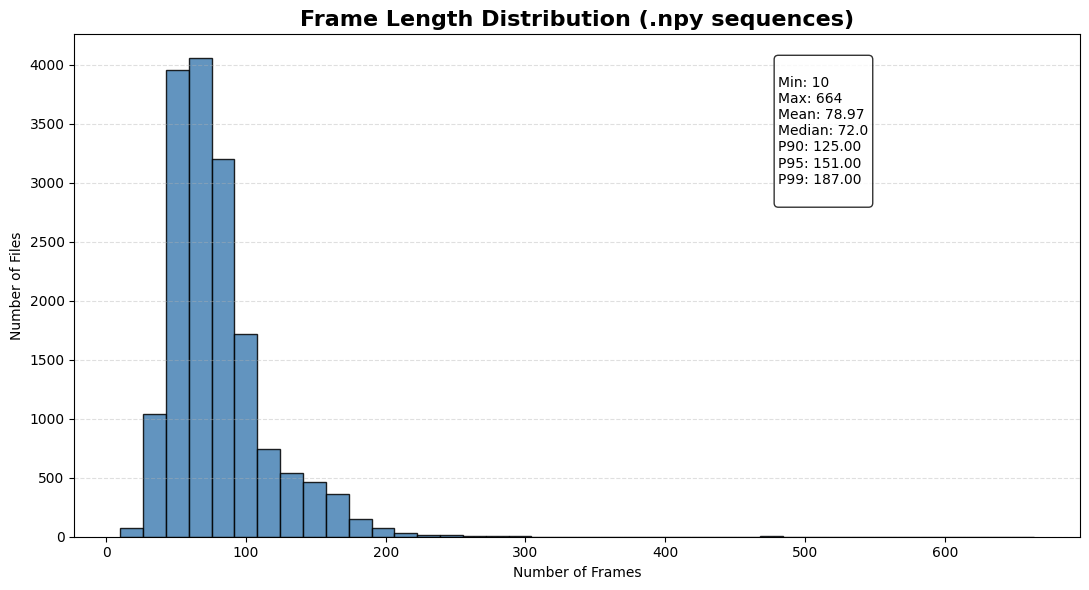

In [43]:
# PLOT
plt.figure(figsize=(11, 6))
plt.hist(frame_counts, bins=40, color="steelblue", edgecolor="black", alpha=0.85)
plt.title("Frame Length Distribution (.npy sequences)", fontsize=16, fontweight="bold")
plt.xlabel("Number of Frames")
plt.ylabel("Number of Files")
plt.grid(axis="y", linestyle="--", alpha=0.4)
# stats box
text = f"""
Min: {min_v}
Max: {max_v}
Mean: {mean_v:.2f}
Median: {median_v}
P90: {p90:.2f}
P95: {p95:.2f}
P99: {p99:.2f}
"""

plt.gca().text(
    0.70, 0.95, text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
# save
plt.savefig(output_dir / "frame_stats_summary.png", dpi=300, bbox_inches="tight")
plt.show()